# Đánh giá 3 phiên bản model trên `DataSet/DataRealTest`

Notebook này so sánh 3 checkpoint:

- **V1**: `Train/outputs/best_model.pth`
- **V2**: `Train/outputs_v2/best_model_v2.pth`
- **V3 BU**: `Train/outputs_v3_BU/best_model_p6_v3.pth`

Mục tiêu là đo lại độ chính xác trên một mẫu nhỏ từ `DataSet/DataRealTest`, rồi hiển thị mức cải thiện của model sau so với model trước bằng accuracy, balanced accuracy, macro F1 và một điểm tổng hợp `smart_score`.

In [25]:
from pathlib import Path
import sys
import json
import math
import random
import time
import warnings

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image, ImageFile
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore", category=UserWarning)
ImageFile.LOAD_TRUNCATED_IMAGES = True
sns.set_theme(style="whitegrid")

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "Train").exists() and (candidate / "DataSet" / "DataRealTest").exists():
            return candidate
    raise RuntimeError("Không tìm thấy project root có Train/ và DataSet/DataRealTest/.")

PROJECT_ROOT = find_project_root()
TRAIN_DIR = PROJECT_ROOT / "Train"
DATA_DIR = PROJECT_ROOT / "DataSet" / "DataRealTest"
REPORT_DIR = TRAIN_DIR / "eval_reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

if str(TRAIN_DIR) not in sys.path:
    sys.path.insert(0, str(TRAIN_DIR))

from export import WasteDetector

print("Project root:", PROJECT_ROOT)
print("Data dir    :", DATA_DIR)
print("Report dir  :", REPORT_DIR)
print("Torch       :", torch.__version__)

Project root: /Users/capkimkhanh/Documents/DUT/PBL5/Model
Data dir    : /Users/capkimkhanh/Documents/DUT/PBL5/Model/DataSet/DataRealTest
Report dir  : /Users/capkimkhanh/Documents/DUT/PBL5/Model/Train/eval_reports
Torch       : 2.11.0


## Cấu hình chạy

- `MAX_IMAGES_PER_CLASS = 30`: lấy tối đa 30 ảnh mỗi class để chạy nhanh.
- Đổi thành `None` nếu muốn dùng toàn bộ `DataSet/DataRealTest`.
- `DEVICE` tự chọn `mps`, `cuda`, rồi đến `cpu`.

In [26]:
SEED = 42
MAX_IMAGES_PER_CLASS = 30  # đổi thành None để đánh giá toàn bộ DataSet/DataRealTest
BATCH_SIZE = 16
NUM_WORKERS = 0
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

MODEL_SPECS = [
    {
        "name": "V1_outputs",
        "label": "V1",
        "checkpoint": TRAIN_DIR / "outputs" / "best_model.pth",
        "meta": TRAIN_DIR / "outputs" / "model_meta.json",
    },
    {
        "name": "V2_outputs_v2",
        "label": "V2",
        "checkpoint": TRAIN_DIR / "outputs_v2" / "best_model_v2.pth",
        "meta": TRAIN_DIR / "outputs_v2" / "model_meta.json",
    },
    {
        "name": "V3_BU_outputs_v3_BU",
        "label": "V3",
        "checkpoint": TRAIN_DIR / "outputs_v3_BU" / "best_model_p6_v3.pth",
        "meta": TRAIN_DIR / "outputs_v3_BU" / "model_meta_v3.json",
    },
]

def pick_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = pick_device()
print("Device:", DEVICE)

for spec in MODEL_SPECS:
    print(f"{spec['label']:<24} ckpt={spec['checkpoint'].exists()} meta={spec['meta'].exists()}")

Device: mps
V1                       ckpt=True meta=True
V2                       ckpt=True meta=True
V3                       ckpt=True meta=True


In [27]:
def read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

latest_meta = read_json(MODEL_SPECS[-1]["meta"])
BASE_CLASSES = latest_meta.get(
    "classes",
    ["Battery", "Biological", "General_Waste", "Glass", "Metal", "Paper_Cardboard", "Plastic"],
)
CLASS_TO_IDX = {name: idx for idx, name in enumerate(BASE_CLASSES)}
print("Classes:", BASE_CLASSES)

def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

class FastAdaptiveGamma:
    def __init__(self, target: int = 128, g_min: float = 0.4, g_max: float = 3.0):
        self.target = float(np.clip(target, 8, 247))
        self.g_min = float(g_min)
        self.g_max = float(g_max)
        self._idx = np.arange(256, dtype=np.float64) / 255.0
        self._last_gamma = -1.0
        self._lut = None

    def _compute_gamma(self, mean_v: float) -> float:
        mean_v = float(np.clip(mean_v, 8.0, 247.0))
        log_mean = math.log(mean_v / 255.0)
        log_target = math.log(self.target / 255.0)
        if abs(log_mean - log_target) < 0.03:
            return 1.0
        return float(np.clip(log_target / log_mean, self.g_min, self.g_max))

    def __call__(self, pil_img: Image.Image) -> Image.Image:
        arr = np.array(pil_img, dtype=np.uint8)
        mean_v = float(arr.max(axis=2).mean())
        gamma = self._compute_gamma(mean_v)
        if abs(gamma - 1.0) < 0.02:
            self._last_gamma = gamma
            return pil_img
        if self._lut is None or abs(gamma - self._last_gamma) > 0.005:
            lut = np.power(self._idx, gamma) * 255.0
            self._lut = lut.clip(0, 255).astype(np.uint8)
        self._last_gamma = gamma
        return Image.fromarray(cv2.LUT(arr, self._lut))

def build_val_transform(meta: dict):
    img_size = int(meta.get("img_size", 384))
    agc = FastAdaptiveGamma(
        target=int(meta.get("agc_target", 128)),
        g_min=float(meta.get("agc_gamma_min", 0.4)),
        g_max=float(meta.get("agc_gamma_max", 3.0)),
    )
    return transforms.Compose([
        transforms.Resize(int(img_size * 1.15)),
        agc,
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

Classes: ['Battery', 'Biological', 'General_Waste', 'Glass', 'Metal', 'Paper_Cardboard', 'Plastic']


In [28]:
def collect_realtest_samples(
    data_dir: Path,
    classes: list[str],
    max_per_class: int | None = 30,
    seed: int = 42,
) -> pd.DataFrame:
    rng = random.Random(seed)
    rows = []
    for class_name in classes:
        class_dir = data_dir / class_name
        if not class_dir.exists():
            print(f"[WARN] Thiếu folder class: {class_dir}")
            continue
        files = [p for p in sorted(class_dir.rglob("*")) if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
        rng.shuffle(files)
        if max_per_class is not None:
            files = files[:max_per_class]
        for path in files:
            rows.append({"path": path, "label": class_name, "label_idx": CLASS_TO_IDX[class_name]})
    rng.shuffle(rows)
    if not rows:
        raise RuntimeError(f"Không tìm thấy ảnh hợp lệ trong {data_dir}")
    return pd.DataFrame(rows)

samples_df = collect_realtest_samples(DATA_DIR, BASE_CLASSES, MAX_IMAGES_PER_CLASS, SEED)
print(f"Tổng ảnh đánh giá: {len(samples_df):,}")
display(samples_df.groupby("label").size().rename("n_images").reindex(BASE_CLASSES).to_frame())

Tổng ảnh đánh giá: 205


,n_images
label,
Battery,30
Biological,30
General_Waste,30
Glass,25
Metal,30
Paper_Cardboard,30
Plastic,30


In [29]:
class RealTestDataset(Dataset):
    def __init__(self, samples: pd.DataFrame, transform):
        self.samples = samples.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        row = self.samples.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        tensor = self.transform(image)
        return tensor, int(row["label_idx"]), str(row["path"])


def load_model_from_spec(spec: dict, device: torch.device):
    meta = read_json(spec["meta"])
    ckpt = safe_torch_load(spec["checkpoint"])
    classes = ckpt.get("classes") or meta.get("classes") or BASE_CLASSES
    if list(classes) != list(BASE_CLASSES):
        raise ValueError(f"Class order khác BASE_CLASSES ở {spec['label']}: {classes}")

    model = WasteDetector(num_classes=len(classes))
    state_dict = ckpt.get("model_state", ckpt.get("model_state_dict", ckpt))
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing or unexpected:
        print(f"[WARN] {spec['label']} missing={len(missing)} unexpected={len(unexpected)}")

    model.to(device).eval()
    checkpoint_info = {
        "checkpoint_epoch": ckpt.get("epoch"),
        "checkpoint_val_acc": ckpt.get("val_acc"),
        "checkpoint_real_val_acc": ckpt.get("real_val_acc"),
        "source": ckpt.get("source"),
        "phase": meta.get("phase"),
    }
    return model, meta, checkpoint_info


def evaluate_model(spec: dict, samples: pd.DataFrame, device: torch.device) -> tuple[dict, pd.DataFrame, pd.DataFrame, np.ndarray]:
    model, meta, checkpoint_info = load_model_from_spec(spec, device)
    transform = build_val_transform(meta)
    dataset = RealTestDataset(samples, transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    y_true, y_pred, confidences, objectness_scores, paths = [], [], [], [], []
    started = time.time()

    with torch.inference_mode():
        for images, labels, batch_paths in loader:
            images = images.to(device, non_blocking=True)
            logits, objectness = model(images)
            probs = torch.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)
            obj = torch.sigmoid(objectness.flatten())

            y_true.extend(labels.numpy().tolist())
            y_pred.extend(pred.detach().cpu().numpy().tolist())
            confidences.extend(conf.detach().cpu().numpy().tolist())
            objectness_scores.extend(obj.detach().cpu().numpy().tolist())
            paths.extend(batch_paths)

    elapsed = time.time() - started
    true_names = [BASE_CLASSES[i] for i in y_true]
    pred_names = [BASE_CLASSES[i] for i in y_pred]

    accuracy = accuracy_score(true_names, pred_names)
    balanced = balanced_accuracy_score(true_names, pred_names)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        true_names, pred_names, labels=BASE_CLASSES, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        true_names, pred_names, labels=BASE_CLASSES, average="weighted", zero_division=0
    )
    cm = confusion_matrix(true_names, pred_names, labels=BASE_CLASSES)
    smart_score = 0.50 * accuracy + 0.30 * macro_f1 + 0.20 * balanced

    summary = {
        "model": spec["label"],
        "n_images": len(samples),
        "accuracy": accuracy,
        "balanced_accuracy": balanced,
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "smart_score": smart_score,
        "mean_confidence": float(np.mean(confidences)),
        "mean_objectness": float(np.mean(objectness_scores)),
        "elapsed_sec": elapsed,
        **checkpoint_info,
    }

    report = classification_report(
        true_names,
        pred_names,
        labels=BASE_CLASSES,
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})
    report_df.insert(0, "model", spec["label"])

    pred_df = pd.DataFrame({
        "model": spec["label"],
        "path": paths,
        "true": true_names,
        "pred": pred_names,
        "correct": np.array(true_names) == np.array(pred_names),
        "confidence": confidences,
        "objectness": objectness_scores,
    })

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return summary, report_df, pred_df, cm

In [30]:
all_summaries = []
all_reports = []
all_predictions = []
confusion_matrices = {}

for spec in MODEL_SPECS:
    print(f"\nEvaluating {spec['label']} ...")
    summary, report_df, pred_df, cm = evaluate_model(spec, samples_df, DEVICE)
    all_summaries.append(summary)
    all_reports.append(report_df)
    all_predictions.append(pred_df)
    confusion_matrices[spec["label"]] = cm
    print(
        f"  accuracy={summary['accuracy']:.4f} | macro_f1={summary['macro_f1']:.4f} | "
        f"smart_score={summary['smart_score']:.4f} | {summary['elapsed_sec']:.1f}s"
    )

summary_df = pd.DataFrame(all_summaries)
reports_df = pd.concat(all_reports, ignore_index=True)
predictions_df = pd.concat(all_predictions, ignore_index=True)
summary_df


Evaluating V1 ...
  accuracy=0.7415 | macro_f1=0.7286 | smart_score=0.7365 | 1.4s

Evaluating V2 ...
  accuracy=0.8098 | macro_f1=0.8067 | smart_score=0.8084 | 1.4s

Evaluating V3 ...
  accuracy=0.9073 | macro_f1=0.9075 | smart_score=0.9070 | 1.3s


,model,n_images,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,smart_score,mean_confidence,mean_objectness,elapsed_sec,checkpoint_epoch,checkpoint_val_acc,checkpoint_real_val_acc,source,phase
0,V1,205,0.741463,0.736190,0.763311,0.736190,0.728573,0.732557,0.736542,0.798966,0.498043,1.408758,47,0.975385,NaN,swa,NaN
1,V2,205,0.809756,0.807619,0.821400,0.807619,0.806742,0.807331,0.808424,0.730351,0.501855,1.377937,8,0.987103,NaN,phase6_realworld_model,phase6_realworld
2,V3,205,0.907317,0.905714,0.915112,0.905714,0.907452,0.907789,0.907037,0.743160,0.494496,1.297805,34,0.966342,0.917647,phase6_v3_real_model,phase6_v3_realworld_kd


In [31]:
def add_improvement_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    metric_cols = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "smart_score"]
    for col in metric_cols:
        out[f"{col}_delta_prev_pp"] = out[col].diff() * 100.0
        out[f"{col}_delta_v1_pp"] = (out[col] - out[col].iloc[0]) * 100.0

    error = 1.0 - out["accuracy"]
    prev_error = error.shift(1)
    base_error = error.iloc[0]
    out["error_reduction_vs_prev"] = (prev_error - error) / prev_error.replace(0, np.nan)
    out["error_reduction_vs_v1"] = (base_error - error) / base_error if base_error > 0 else np.nan
    return out

comparison_df = add_improvement_columns(summary_df)

show_cols = [
    "model", "n_images", "accuracy", "accuracy_delta_prev_pp", "accuracy_delta_v1_pp",
    "balanced_accuracy", "macro_f1", "macro_f1_delta_prev_pp", "smart_score",
    "error_reduction_vs_prev", "error_reduction_vs_v1", "checkpoint_val_acc",
    "checkpoint_real_val_acc", "source", "phase",
]

display_df = comparison_df[show_cols].copy()

percent_cols = ["accuracy", "balanced_accuracy", "macro_f1", "smart_score", "checkpoint_val_acc", "checkpoint_real_val_acc"]
pp_cols = ["accuracy_delta_prev_pp", "accuracy_delta_v1_pp", "macro_f1_delta_prev_pp"]
relative_cols = ["error_reduction_vs_prev", "error_reduction_vs_v1"]

styled = (
    display_df.style
    .format({**{c: "{:.2%}" for c in percent_cols}, **{c: "{:+.2f} pp" for c in pp_cols}, **{c: "{:+.2%}" for c in relative_cols}})
    .background_gradient(subset=["accuracy", "balanced_accuracy", "macro_f1", "smart_score"], cmap="Greens")
    .bar(subset=["accuracy_delta_prev_pp", "accuracy_delta_v1_pp", "macro_f1_delta_prev_pp"], align="zero", color=["#d73027", "#1a9850"])
)

display(styled)

best = comparison_df.sort_values("smart_score", ascending=False).iloc[0]
print(f"Model tốt nhất theo smart_score: {best['model']} ({best['smart_score']:.2%})")

,model,n_images,accuracy,accuracy_delta_prev_pp,accuracy_delta_v1_pp,balanced_accuracy,macro_f1,macro_f1_delta_prev_pp,smart_score,error_reduction_vs_prev,error_reduction_vs_v1,checkpoint_val_acc,checkpoint_real_val_acc,source,phase
0,V1,205,74.15%,+nan pp,+0.00 pp,73.62%,72.86%,+nan pp,73.65%,+nan%,+0.00%,97.54%,nan%,swa,nan
1,V2,205,80.98%,+6.83 pp,+6.83 pp,80.76%,80.67%,+7.82 pp,80.84%,+26.42%,+26.42%,98.71%,nan%,phase6_realworld_model,phase6_realworld
2,V3,205,90.73%,+9.76 pp,+16.59 pp,90.57%,90.75%,+10.07 pp,90.70%,+51.28%,+64.15%,96.63%,91.76%,phase6_v3_real_model,phase6_v3_realworld_kd


Model tốt nhất theo smart_score: V3 (90.70%)


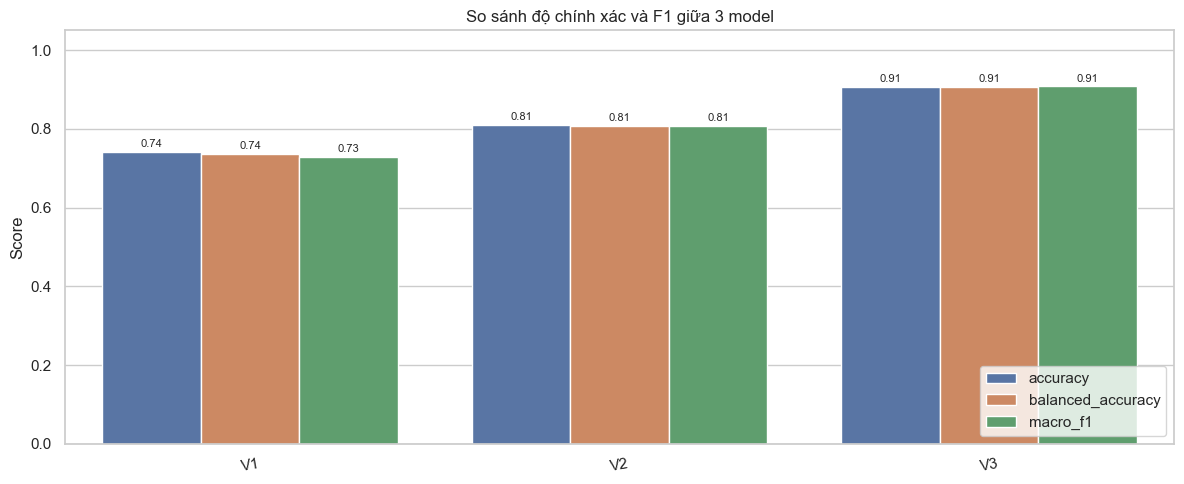

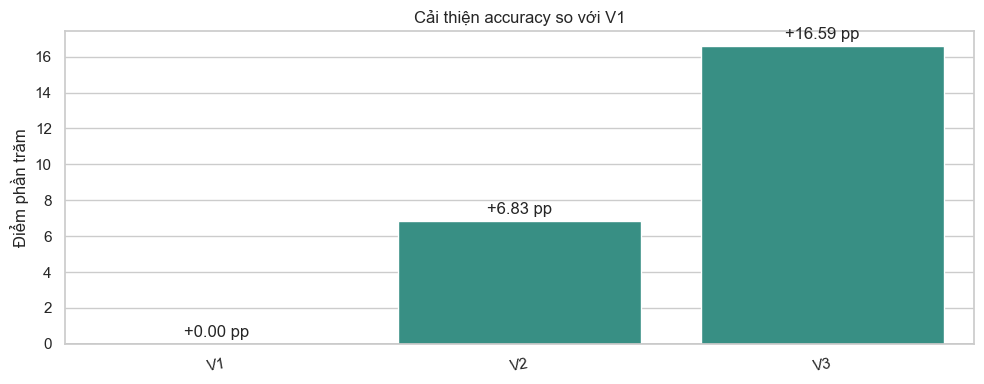

In [32]:
plot_df = comparison_df.melt(
    id_vars="model",
    value_vars=["accuracy", "balanced_accuracy", "macro_f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=plot_df, x="model", y="score", hue="metric")
ax.set_title("So sánh độ chính xác và F1 giữa 3 model")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=10)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
ax = sns.barplot(data=comparison_df, x="model", y="accuracy_delta_v1_pp", color="#2a9d8f")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Cải thiện accuracy so với V1")
ax.set_xlabel("")
ax.set_ylabel("Điểm phần trăm")
ax.tick_params(axis="x", rotation=10)
for container in ax.containers:
    ax.bar_label(container, fmt="%+.2f pp", padding=3)
plt.tight_layout()
plt.show()

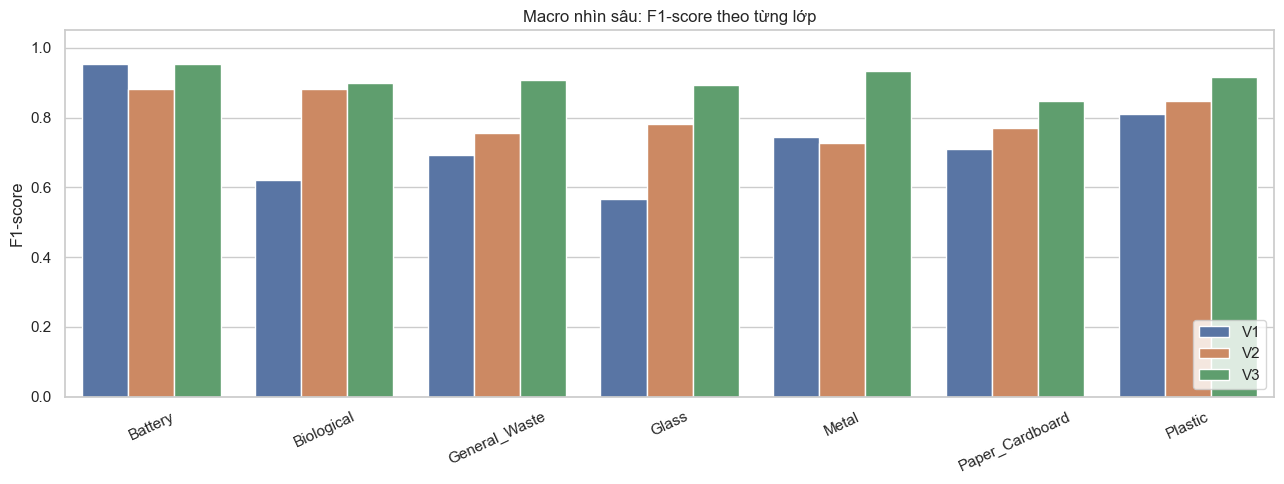

model,V1,V2,V3
class,,,
Battery,95.24%,88.24%,95.24%
Biological,62.22%,88.14%,90.00%
General_Waste,69.23%,75.47%,90.91%
Glass,56.52%,78.26%,89.36%
Metal,74.58%,72.73%,93.33%
Paper_Cardboard,71.05%,77.14%,84.85%
Plastic,81.16%,84.75%,91.53%


In [33]:
class_rows = reports_df[reports_df["class"].isin(BASE_CLASSES)].copy()
class_rows["support"] = class_rows["support"].astype(int)

plt.figure(figsize=(13, 5))
ax = sns.barplot(data=class_rows, x="class", y="f1-score", hue="model")
ax.set_title("Macro nhìn sâu: F1-score theo từng lớp")
ax.set_xlabel("")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

display(
    class_rows.pivot(index="class", columns="model", values="f1-score")
    .reindex(BASE_CLASSES)
    .style.format("{:.2%}")
    .background_gradient(cmap="Greens", axis=1)
)

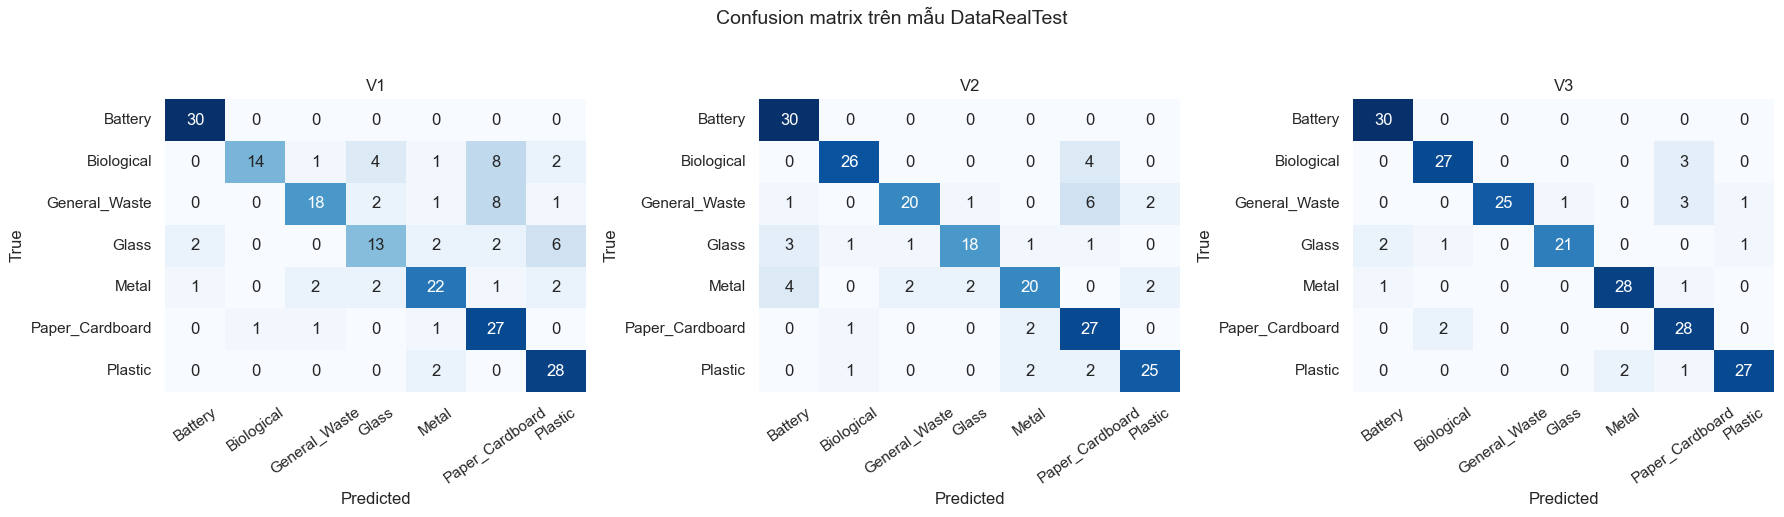

In [34]:
fig, axes = plt.subplots(1, len(MODEL_SPECS), figsize=(6 * len(MODEL_SPECS), 5), squeeze=False)
for ax, spec in zip(axes[0], MODEL_SPECS):
    label = spec["label"]
    cm = confusion_matrices[label]
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=BASE_CLASSES,
        yticklabels=BASE_CLASSES,
        cbar=False,
        ax=ax,
    )
    ax.set_title(label)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)
plt.suptitle("Confusion matrix trên mẫu DataRealTest", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
def top_mistakes(pred_df: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    wrong = pred_df[~pred_df["correct"]].copy()
    if wrong.empty:
        return pd.DataFrame(columns=["true", "pred", "n", "mean_confidence"])
    return (
        wrong.groupby(["true", "pred"])
        .agg(n=("path", "size"), mean_confidence=("confidence", "mean"))
        .reset_index()
        .sort_values(["n", "mean_confidence"], ascending=[False, False])
        .head(n)
    )

for spec in MODEL_SPECS:
    label = spec["label"]
    print("\n", label)
    mistakes = top_mistakes(predictions_df[predictions_df["model"] == label], n=8)
    display(mistakes.style.format({"mean_confidence": "{:.2%}"}))


 V1


,true,pred,n,mean_confidence
3,Biological,Paper_Cardboard,8,78.24%
7,General_Waste,Paper_Cardboard,8,70.16%
12,Glass,Plastic,6,61.26%
1,Biological,Glass,4,55.35%
21,Plastic,Metal,2,69.01%
9,Glass,Battery,2,62.97%
15,Metal,Glass,2,58.43%
10,Glass,Metal,2,58.08%



 V2


,true,pred,n,mean_confidence
3,General_Waste,Paper_Cardboard,6,55.61%
0,Biological,Paper_Cardboard,4,78.13%
10,Metal,Battery,4,58.92%
5,Glass,Battery,3,54.87%
11,Metal,General_Waste,2,59.66%
12,Metal,Glass,2,57.58%
17,Plastic,Metal,2,54.09%
4,General_Waste,Plastic,2,49.99%



 V3


,true,pred,n,mean_confidence
0,Biological,Paper_Cardboard,3,67.22%
2,General_Waste,Paper_Cardboard,3,43.35%
10,Plastic,Metal,2,64.21%
4,Glass,Battery,2,48.49%
9,Paper_Cardboard,Biological,2,46.21%
8,Metal,Paper_Cardboard,1,54.35%
1,General_Waste,Glass,1,43.70%
3,General_Waste,Plastic,1,39.08%


In [36]:
summary_path = REPORT_DIR / "eval_model_summary.csv"
report_path = REPORT_DIR / "eval_model_classification_reports.csv"
pred_path = REPORT_DIR / "eval_model_predictions.csv"

comparison_df.to_csv(summary_path, index=False)
reports_df.to_csv(report_path, index=False)
predictions_df.to_csv(pred_path, index=False)

print("Đã lưu report:")
print("-", summary_path)
print("-", report_path)
print("-", pred_path)

Đã lưu report:
- /Users/capkimkhanh/Documents/DUT/PBL5/Model/Train/eval_reports/eval_model_summary.csv
- /Users/capkimkhanh/Documents/DUT/PBL5/Model/Train/eval_reports/eval_model_classification_reports.csv
- /Users/capkimkhanh/Documents/DUT/PBL5/Model/Train/eval_reports/eval_model_predictions.csv
